# 01. Heterogeneous Treatment Effects

Average treatment effects answer whether the intervention worked on average. Industry decisions usually also ask who benefited enough to justify action.

This lecture introduces heterogeneous treatment effects (HTE) and the conditional average treatment effect (CATE). We will use a randomized customer-retention experiment to show why treatment effect heterogeneity matters, how to estimate it with transparent subgroup methods and simple interaction models, and how to connect the estimates to a targeting decision.

## Learning Goals

By the end of this notebook, you should be able to:

- Define the CATE, subgroup treatment effects, and the relationship between them and the ATE.
- Explain why a strong average effect can still hide unprofitable treatment decisions for some customers.
- Separate prognostic variables from effect modifiers.
- Estimate HTEs with subgroup comparisons, interaction models, and an honest sample-splitting workflow.
- Evaluate a treatment targeting rule using a holdout sample and a known simulation benchmark.
- Translate HTE results into an industry readout that is useful for product, marketing, and operations teams.

### Dataset and Experiment Setup

This notebook uses a simulated retention experiment for existing customers. The observational unit is a customer account. Pre-treatment variables describe usage, churn risk, account value, tenure, support history, and other signals that a business team would normally have before deciding whether to intervene. The treatment is a customer-success outreach or retention intervention, and the outcome is a value or retention measure after the intervention window.

The experiment is simulated because the notebook needs the true individual treatment effect and true CATE function. In real retention data, we would observe only one potential outcome per customer. Here, the hidden truth is available so we can ask whether interaction models, subgroup summaries, and CATE diagnostics recover the real heterogeneity. The realism comes from nonuniform baseline risk, heterogeneous response, noise, and overlap concerns while the example remains shareable.


In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def sigmoid(x):
    """Compute sigmoid for the heterogeneous treatment effects example.
    
    Inputs:
    - `x`: logit-scale numeric input converted into a probability.
    Returns: a NumPy array or scalar of logistic probabilities."""
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Construct the dag object.
    
    Inputs:
    - `edges`: directed or undirected graph edges represented as node pairs.
    - `title`: plot or graph title displayed above the figure.
    - `node_colors`: optional mapping from graph nodes to fill colors.
    - `rankdir`: Graphviz layout direction, such as left-to-right or top-to-bottom.
    Returns: a Graphviz diagram for the causal structure in the section."""
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def difference_in_means(frame, outcome="outcome", treatment="treatment"):
    """Compute difference in means for the heterogeneous treatment effects example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a treatment-control difference with its uncertainty summary."""
    treated = frame.loc[frame[treatment] == 1, outcome]
    control = frame.loc[frame[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return {
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "n_treated": treated.size,
        "n_control": control.size,
    }


def subgroup_effect_table(frame, group_col, outcome="outcome", treatment="treatment"):
    """Compute subgroup effect table for the heterogeneous treatment effects example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `group_col`: name of the subgroup column used to estimate heterogeneous effects by group.
    - `outcome`: name of the observed outcome column whose causal contrast is being estimated.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: an effect-estimate summary for the causal comparison in the section."""
    rows = []
    for group_name, group_frame in frame.groupby(group_col, observed=True):
        stats = difference_in_means(group_frame, outcome=outcome, treatment=treatment)
        rows.append(
            {
                "group": str(group_name),
                "n": len(group_frame),
                "n_treated": stats["n_treated"],
                "n_control": stats["n_control"],
                "estimated_effect": stats["estimate"],
                "std_error": stats["std_error"],
                "ci_low": stats["ci_low"],
                "ci_high": stats["ci_high"],
                "true_cate_mean": group_frame["true_cate"].mean(),
                "mean_risk_score": group_frame["risk_score"].mean(),
            }
        )
    return pd.DataFrame(rows)


def plot_effect_table(table, title, xlabel="Treatment effect", reference=None, figsize=(8, 4)):
    """Plot the effect table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_data = table.copy().reset_index(drop=True)
    y = np.arange(len(plot_data))
    xerr = np.vstack(
        [
            plot_data["estimated_effect"] - plot_data["ci_low"],
            plot_data["ci_high"] - plot_data["estimated_effect"],
        ]
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        plot_data["estimated_effect"],
        y,
        xerr=xerr,
        fmt="o",
        color="#1f77b4",
        ecolor="#94a3b8",
        capsize=4,
        label="Estimated effect",
    )
    ax.scatter(plot_data["true_cate_mean"], y, marker="D", color="#dc2626", label="True mean CATE")
    ax.axvline(0, color="#334155", linewidth=1, linestyle="--")
    if reference is not None:
        ax.axvline(reference, color="#16a34a", linewidth=1.5, linestyle=":", label="Overall true ATE")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["group"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


def standardize_features(train, test, feature_cols):
    """Standardize training and test features with training-sample moments.
    
    Inputs:
    - `train`: training DataFrame used to learn preprocessing, nuisance, or effect-model quantities.
    - `test`: test or validation DataFrame used to evaluate learned quantities out of sample.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    Returns: the transformed train/test matrices plus the means and standard deviations needed for later predictions."""
    means = train[feature_cols].mean()
    stds = train[feature_cols].std(ddof=0).replace(0, 1)
    return (train[feature_cols] - means) / stds, (test[feature_cols] - means) / stds, means, stds


def interaction_design(frame, feature_cols, means, stds, treatment="treatment"):
    """Build the regression design matrix with treatment-by-feature interactions.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    - `means`: training-sample feature means used to center new design matrices.
    - `stds`: training-sample feature standard deviations used to scale new design matrices.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: a pandas DataFrame containing the intercept, treatment, centered covariates, and interaction terms."""
    x_std = (frame[feature_cols] - means) / stds
    design = pd.DataFrame(index=frame.index)
    design["const"] = 1.0
    design[treatment] = frame[treatment].astype(float)
    for col in feature_cols:
        design[col] = x_std[col].astype(float)
        design[f"{treatment}_x_{col}"] = frame[treatment].astype(float) * x_std[col].astype(float)
    return design


def predict_cate_from_interaction(model, frame, feature_cols, means, stds, treatment="treatment"):
    """Generate cate from interaction predictions.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `feature_cols`: list of pre-treatment covariate column names used as model features or effect modifiers.
    - `means`: training-sample feature means used to center new design matrices.
    - `stds`: training-sample feature standard deviations used to scale new design matrices.
    - `treatment`: name of the treatment-assignment column, usually coded as treated versus control.
    Returns: predicted effects, rewards, or outcomes for the rows passed into the function."""
    x_std = (frame[feature_cols] - means) / stds
    cate_hat = pd.Series(model.params[treatment], index=frame.index, dtype=float)
    for col in feature_cols:
        cate_hat += model.params.get(f"{treatment}_x_{col}", 0.0) * x_std[col]
    return cate_hat

## 1. Where Heterogeneous Effects Fit

Many earlier notebooks focused on identifying an average causal effect. That is the right starting point when the business question is, "Did the intervention work?" HTE becomes necessary when the question becomes, "Who should receive the intervention next?"

Examples:

- Marketing: Which customers should receive a retention offer?
- Product: Which users benefit from onboarding assistance?
- Pricing: Which accounts are harmed by a discount because it trains them to wait for promotions?
- Operations: Which support tickets should be routed to a specialist queue?
- Healthcare: Which patients benefit from a treatment enough to justify side effects or cost?

The main idea is simple: two customers can have the same expected outcome under the current policy but very different expected gains from the new policy. Causal machine learning tries to learn that difference, not just the outcome level.

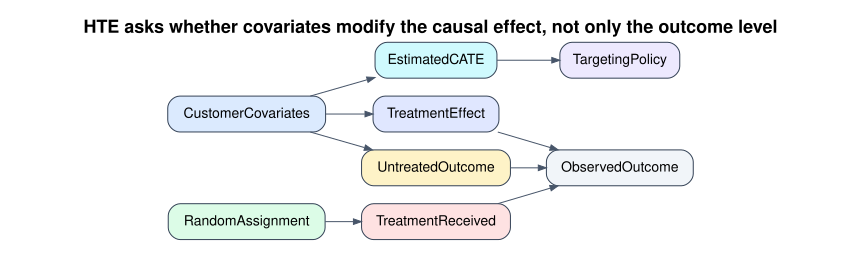

In [3]:
make_dag(
    edges=[
        ("CustomerCovariates", "UntreatedOutcome"),
        ("CustomerCovariates", "TreatmentEffect"),
        ("RandomAssignment", "TreatmentReceived"),
        ("TreatmentReceived", "ObservedOutcome"),
        ("UntreatedOutcome", "ObservedOutcome"),
        ("TreatmentEffect", "ObservedOutcome"),
        ("EstimatedCATE", "TargetingPolicy"),
        ("CustomerCovariates", "EstimatedCATE"),
    ],
    title="HTE asks whether covariates modify the causal effect, not only the outcome level",
    node_colors={
        "CustomerCovariates": "#dbeafe",
        "RandomAssignment": "#dcfce7",
        "TreatmentReceived": "#fee2e2",
        "UntreatedOutcome": "#fef3c7",
        "TreatmentEffect": "#e0e7ff",
        "ObservedOutcome": "#f1f5f9",
        "EstimatedCATE": "#cffafe",
        "TargetingPolicy": "#ede9fe",
    },
)

The modern HTE literature includes several related streams. Athey and Imbens (2016) developed recursive partitioning methods tailored to heterogeneous causal effects. Wager and Athey (2018) extended this idea to causal forests for nonparametric estimation and inference. Kunzel et al. (2019) organized several "metalearner" strategies that adapt ordinary supervised learning algorithms to estimate CATEs. Hahn et al. (2020) developed Bayesian causal forests for settings with confounding and heterogeneous effects. We will use only simple tools here, but the conceptual spine is the same.

## 2. Estimands: ATE, Subgroup Effects, and CATE

For a binary treatment $W \in \{0, 1\}$, let $Y(1)$ be the potential outcome under treatment and $Y(0)$ be the potential outcome under control.

The individual causal effect is:

$$
Y_i(1) - Y_i(0)
$$

The problem is that we never observe both potential outcomes for the same unit. So most causal estimands average this missing contrast over a population.

The average treatment effect is:

$$
ATE = E[Y(1) - Y(0)]
$$

A subgroup treatment effect averages over a group $G$:

$$
E[Y(1) - Y(0) \mid G]
$$

The conditional average treatment effect conditions on features $X=x$:

$$
\tau(x) = E[Y(1) - Y(0) \mid X=x]
$$

The ATE is the population average of the CATE:

$$
ATE = E[\tau(X)]
$$

This relationship matters in practice. If the CATE varies a lot, the ATE can be a poor guide for a constrained targeting decision.

## 3. Running Example: Retention Outreach

Imagine a SaaS company runs a randomized experiment. Half of eligible accounts receive a proactive retention offer; half do not. The outcome is next-quarter net revenue from the account. Higher is better.

The company has a budget constraint. It cannot contact every account every quarter. The decision is therefore not merely whether the offer works on average. The decision is which accounts should receive it.

We will simulate the experiment so that the ground truth is known. Real projects lack access to the true CATE. Simulation lets us check whether our estimators are learning the right pattern.

In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_retention_experiment(n=12_000, seed=5101):
    """Simulate the retention experiment data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)

    risk_score = rng.beta(2.2, 2.8, n)
    usage_z = rng.normal(0, 1, n)
    customer_value = rng.lognormal(mean=4.2, sigma=0.55, size=n)
    tenure_months = rng.gamma(shape=2.2, scale=10, size=n)
    enterprise_plan = rng.binomial(1, sigmoid(-0.4 + 0.55 * (np.log(customer_value) - 4.2)))
    support_tickets = rng.poisson(np.clip(1.2 + 2.5 * risk_score - 0.3 * usage_z, 0.1, None))

    treatment = rng.binomial(1, 0.5, n)

    mu0 = (
        65
        + 0.16 * customer_value
        + 6.0 * usage_z
        - 10.0 * risk_score
        + 4.0 * enterprise_plan
        + 0.12 * tenure_months
        - 1.5 * support_tickets
        + 3.0 * np.sin(usage_z)
    )

    true_cate = (
        -4.0
        + 15.0 * risk_score
        + 2.5 * enterprise_plan
        - 2.0 * (usage_z > 1.0).astype(float)
        + 1.5 * (support_tickets >= 4).astype(float)
    )

    true_y0 = mu0 + rng.normal(0, 6, n)
    true_y1 = true_y0 + true_cate
    outcome = np.where(treatment == 1, true_y1, true_y0)

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "risk_score": risk_score,
            "usage_z": usage_z,
            "customer_value": customer_value,
            "tenure_months": tenure_months,
            "enterprise_plan": enterprise_plan,
            "support_tickets": support_tickets,
            "treatment": treatment,
            "true_y0": true_y0,
            "true_y1": true_y1,
            "outcome": outcome,
            "true_cate": true_cate,
            "mu0": mu0,
        }
    )


df = simulate_retention_experiment()

summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Treatment share",
            "Average observed outcome",
            "True average treatment effect",
            "Share with positive true CATE",
        ],
        "value": [
            len(df),
            df["treatment"].mean(),
            df["outcome"].mean(),
            df["true_cate"].mean(),
            (df["true_cate"] > 0).mean(),
        ],
    }
)

display(summary)
display(df.head())

,quantity,value
0,Accounts,12000.000
1,Treatment share,0.503
2,Average observed outcome,75.456
3,True average treatment effect,3.545
4,Share with positive true CATE,0.826


,account_id,risk_score,usage_z,customer_value,tenure_months,enterprise_plan,support_tickets,treatment,true_y0,true_y1,outcome,true_cate,mu0
0,1,0.366,-0.093,40.829,7.098,0,0,1,62.106,63.603,63.603,1.497,67.886
1,2,0.510,1.814,89.383,13.337,1,6,0,93.132,98.776,93.132,5.644,84.601
2,3,0.598,-0.205,75.784,35.492,1,2,1,78.781,86.250,86.250,7.469,74.568
3,4,0.284,-0.270,362.404,10.335,1,1,1,116.755,119.509,119.509,2.754,121.466
4,5,0.540,1.222,42.532,28.366,0,3,1,68.803,70.901,70.901,2.098,75.461


The treatment is randomized, so treatment assignment is independent of the customer features. That makes the ATE easy to estimate. The hard part is that each account still contributes only one observed outcome.

In the simulated data we store both potential outcomes for teaching purposes. In a real experiment, the untreated potential outcome for treated accounts and the treated potential outcome for control accounts are counterfactual and therefore unobserved.

In [5]:
sample_units = df.sample(8, random_state=12).copy()
sample_units["observed_arm"] = np.where(sample_units["treatment"] == 1, "treated", "control")
sample_units["counterfactual_not_observed"] = np.where(
    sample_units["treatment"] == 1,
    "Y(0)",
    "Y(1)",
)

display(
    sample_units[
        [
            "account_id",
            "observed_arm",
            "risk_score",
            "usage_z",
            "support_tickets",
            "outcome",
            "true_y0",
            "true_y1",
            "true_cate",
            "counterfactual_not_observed",
        ]
    ].round(3)
)

,account_id,observed_arm,risk_score,usage_z,support_tickets,outcome,true_y0,true_y1,true_cate,counterfactual_not_observed
437,438,control,0.642,-0.890,5,57.666,57.666,64.797,7.131,Y(1)
7619,7620,treated,0.958,-1.784,2,54.391,44.024,54.391,10.366,Y(0)
4014,4015,treated,0.641,0.253,2,77.639,72.029,77.639,5.609,Y(0)
3862,3863,treated,0.109,-0.165,1,74.136,76.506,74.136,-2.370,Y(0)
4351,4352,control,0.322,-1.482,1,65.522,65.522,66.354,0.832,Y(1)
1850,1851,treated,0.252,-0.882,4,51.176,49.890,51.176,1.285,Y(0)
3202,3203,treated,0.711,-0.157,3,75.472,66.301,75.472,9.172,Y(0)
1155,1156,control,0.414,-1.213,2,63.590,63.590,65.797,2.207,Y(1)


The table is intentionally a little uncomfortable: it shows the hidden potential outcomes because we are in a simulation. In live experimentation, the `true_y0`, `true_y1`, and `true_cate` columns are exactly what we wish we had and do not observe.

## 4. Start With the Average Effect

Because the experiment is randomized, the difference in mean outcomes between treated and control accounts is an unbiased estimate of the ATE:

$$
E[Y \mid W=1] - E[Y \mid W=0]
$$

This is still the first thing to report. HTE analysis should not replace the average effect; it should explain where the average effect comes from and whether the treatment should be targeted.

In [6]:
ate_stats = difference_in_means(df)
ate_table = pd.DataFrame(
    {
        "quantity": [
            "Estimated ATE",
            "Robust standard error",
            "95% CI lower",
            "95% CI upper",
            "True ATE from simulation",
            "Estimation error",
        ],
        "value": [
            ate_stats["estimate"],
            ate_stats["std_error"],
            ate_stats["ci_low"],
            ate_stats["ci_high"],
            df["true_cate"].mean(),
            ate_stats["estimate"] - df["true_cate"].mean(),
        ],
    }
)

display(ate_table.round(3))

,quantity,value
0,Estimated ATE,3.634
1,Robust standard error,0.240
2,95% CI lower,3.163
3,95% CI upper,4.104
4,True ATE from simulation,3.545
5,Estimation error,0.089


The estimated ATE is close to the true simulated ATE. If the company only needed a yes-or-no answer about the offer, this would be a strong start.

But the positive average effect does not tell us whether every account should be contacted. The average can be positive even when some accounts have small, zero, or negative effects.

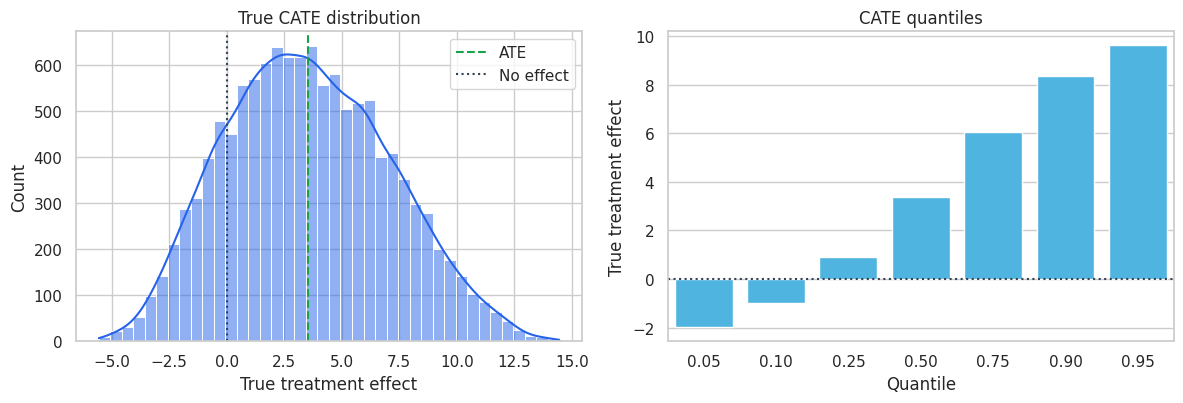

,quantity,value
0,True ATE,3.545
1,True CATE standard deviation,3.539
2,Minimum true CATE,-5.554
3,Median true CATE,3.390
4,Maximum true CATE,14.450
5,Share with negative true CATE,0.174


In [7]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(df["true_cate"], bins=40, kde=True, color="#2563eb", ax=axes[0])
axes[0].axvline(df["true_cate"].mean(), color="#16a34a", linestyle="--", label="ATE")
axes[0].axvline(0, color="#334155", linestyle=":", label="No effect")
axes[0].set_title("True CATE distribution")
axes[0].set_xlabel("True treatment effect")
axes[0].legend()

quantiles = df["true_cate"].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).reset_index()
quantiles.columns = ["quantile", "true_cate"]
sns.barplot(data=quantiles, x="quantile", y="true_cate", color="#38bdf8", ax=axes[1])
axes[1].axhline(0, color="#334155", linestyle=":")
axes[1].set_title("CATE quantiles")
axes[1].set_xlabel("Quantile")
axes[1].set_ylabel("True treatment effect")
axes[1].set_xticklabels([f"{q:.2f}" for q in quantiles["quantile"]])

plt.tight_layout()
plt.show()

heterogeneity_summary = pd.DataFrame(
    {
        "quantity": [
            "True ATE",
            "True CATE standard deviation",
            "Minimum true CATE",
            "Median true CATE",
            "Maximum true CATE",
            "Share with negative true CATE",
        ],
        "value": [
            df["true_cate"].mean(),
            df["true_cate"].std(),
            df["true_cate"].min(),
            df["true_cate"].median(),
            df["true_cate"].max(),
            (df["true_cate"] < 0).mean(),
        ],
    }
)

display(heterogeneity_summary.round(3))

The offer has a positive average effect, but not everyone benefits. This is the central reason HTE analysis matters. A policy that treats all eligible accounts may be acceptable when the intervention is cheap and harmless. A policy with cost, capacity limits, or customer-experience risk should use the heterogeneity.

## 5. Transparent Subgroup Effects

Before using flexible machine learning, start with interpretable subgroup estimates. They are easy to explain, easy to audit, and often enough to identify the main pattern.

Here we split accounts into risk-score quintiles. Within each quintile, treatment was still randomized, so a difference in means estimates the subgroup treatment effect.

,group,n,n_treated,n_control,estimated_effect,std_error,ci_low,ci_high,true_cate_mean,mean_risk_score
0,Q1 lowest risk,2400,1194,1206,-0.659,0.524,-1.686,0.368,-0.719,0.164
1,Q2,2400,1203,1197,0.703,0.518,-0.312,1.718,1.570,0.309
2,Q3,2400,1206,1194,4.355,0.534,3.307,5.402,3.345,0.424
3,Q4,2400,1232,1168,5.219,0.534,4.172,6.265,5.349,0.549
4,Q5 highest risk,2400,1203,1197,8.614,0.541,7.555,9.674,8.180,0.736


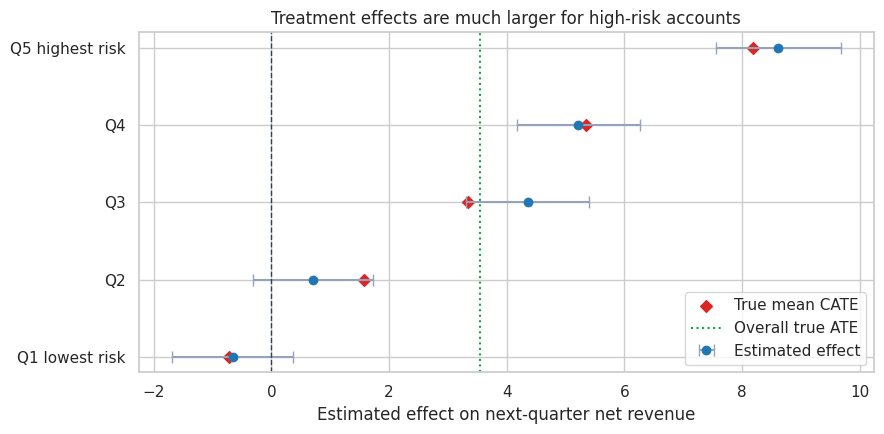

In [8]:
df["risk_quintile"] = pd.qcut(
    df["risk_score"],
    q=5,
    labels=["Q1 lowest risk", "Q2", "Q3", "Q4", "Q5 highest risk"],
)

risk_table = subgroup_effect_table(df, "risk_quintile")
display(risk_table.round(3))

plot_effect_table(
    risk_table,
    title="Treatment effects are much larger for high-risk accounts",
    xlabel="Estimated effect on next-quarter net revenue",
    reference=df["true_cate"].mean(),
    figsize=(9, 4.5),
)
plt.show()

The subgroup pattern is clear. High-risk accounts benefit more from outreach. The low-risk group has little need for the intervention and can even have a negative effect in this simulation. That pattern is plausible in many product settings because unnecessary interventions can annoy low-risk customers, discount customers who would have stayed anyway, or consume support capacity without much gain.

Subgroup analysis has two advantages:

- It is directly connected to a decision rule: treat higher-risk accounts first.
- It gives stakeholders a concrete mental model before more flexible models are introduced.

It also has limitations. Quintiles are arbitrary, and one feature at a time cannot represent interactions such as "high risk and enterprise plan" or "high risk and already very engaged."

## 6. Prognostic Variables Are Not Automatically Effect Modifiers

A prognostic variable predicts the outcome level. An effect modifier predicts the treatment effect.

These are different roles:

$$
\mu_0(x) = E[Y(0) \mid X=x]
$$

$$
\tau(x) = E[Y(1) - Y(0) \mid X=x]
$$

A customer can have high expected revenue under control and still receive little incremental benefit from outreach. Another customer can have lower expected revenue under control but respond strongly to treatment.

This distinction is one of the most common places where predictive modeling and causal modeling diverge.

,feature,corr_with_untreated_outcome,corr_with_true_cate
0,risk_score,-0.212,0.895
5,support_tickets,-0.330,0.418
4,enterprise_plan,0.212,0.339
2,customer_value,0.547,0.036
3,tenure_months,0.142,-0.003
1,usage_z,0.602,-0.158


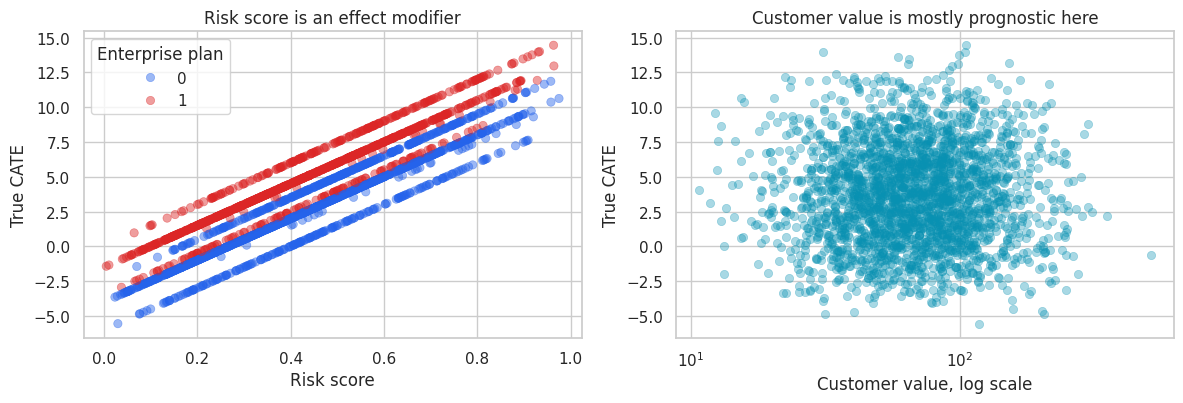

In [9]:
# Build the visualization for the estimates or diagnostics computed above.
feature_cols_raw = [
    "risk_score",
    "usage_z",
    "customer_value",
    "tenure_months",
    "enterprise_plan",
    "support_tickets",
]

correlation_rows = []
for col in feature_cols_raw:
    correlation_rows.append(
        {
            "feature": col,
            "corr_with_untreated_outcome": df[col].corr(df["true_y0"]),
            "corr_with_true_cate": df[col].corr(df["true_cate"]),
        }
    )

corr_table = pd.DataFrame(correlation_rows).sort_values("corr_with_true_cate", ascending=False)
display(corr_table.round(3))

sample_for_plot = df.sample(2500, random_state=44)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.scatterplot(
    data=sample_for_plot,
    x="risk_score",
    y="true_cate",
    hue="enterprise_plan",
    palette=["#2563eb", "#dc2626"],
    alpha=0.45,
    edgecolor=None,
    ax=axes[0],
)
axes[0].set_title("Risk score is an effect modifier")
axes[0].set_xlabel("Risk score")
axes[0].set_ylabel("True CATE")
axes[0].legend(title="Enterprise plan")

sns.scatterplot(
    data=sample_for_plot,
    x="customer_value",
    y="true_cate",
    color="#0891b2",
    alpha=0.35,
    edgecolor=None,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Customer value is mostly prognostic here")
axes[1].set_xlabel("Customer value, log scale")
axes[1].set_ylabel("True CATE")

plt.tight_layout()
plt.show()

The correlation table shows two different kinds of information. Customer value is strongly related to the untreated outcome because valuable accounts generate more revenue even without outreach. Risk score and support tickets are more informative about treatment responsiveness.

A purely predictive model that ranks customers by expected revenue may therefore target expensive accounts that would have stayed anyway. A CATE model tries to rank customers by incremental lift.

## 7. A Linear Interaction Model for CATE

A simple interaction model is often the best first CATE model. It keeps the link between coefficients and business interpretation visible.

The model is:

$$
Y_i = \alpha + \beta W_i + X_i'\gamma + W_i X_i'\delta + \epsilon_i
$$

For a customer with features $x$, the implied CATE is:

$$
\hat{\tau}(x) = \hat{\beta} + x'\hat{\delta}
$$

The interaction coefficients $\delta$ tell us how the treatment effect changes with the features. This model is less flexible than a causal forest or metalearner. It remains a useful baseline and a strong communication tool.

In [10]:
# Fit the models for this section and assemble the estimates used in the discussion.
df_model = df.copy()
df_model["log_customer_value"] = np.log(df_model["customer_value"])

feature_cols = [
    "risk_score",
    "usage_z",
    "log_customer_value",
    "tenure_months",
    "enterprise_plan",
    "support_tickets",
]

train_df, test_df = train_test_split(df_model, test_size=0.35, random_state=27, stratify=df_model["treatment"])
_, _, feature_means, feature_stds = standardize_features(train_df, test_df, feature_cols)

X_train = interaction_design(train_df, feature_cols, feature_means, feature_stds)
y_train = train_df["outcome"].astype(float)

interaction_model = sm.OLS(y_train, X_train).fit(cov_type="HC3")

coef_rows = []
for term in ["treatment"] + [f"treatment_x_{col}" for col in feature_cols]:
    coef_rows.append(
        {
            "term": term,
            "estimate": interaction_model.params[term],
            "std_error": interaction_model.bse[term],
            "ci_low": interaction_model.conf_int().loc[term, 0],
            "ci_high": interaction_model.conf_int().loc[term, 1],
            "p_value": interaction_model.pvalues[term],
        }
    )

interaction_table = pd.DataFrame(coef_rows)
display(interaction_table.round(3))

,term,estimate,std_error,ci_low,ci_high,p_value
0,treatment,3.676,0.152,3.379,3.974,0.000
1,treatment_x_risk_score,3.342,0.161,3.027,3.657,0.000
2,treatment_x_usage_z,-0.488,0.163,-0.807,-0.169,0.003
3,treatment_x_log_customer_value,0.196,0.222,-0.238,0.631,0.376
4,treatment_x_tenure_months,-0.214,0.155,-0.517,0.089,0.166
5,treatment_x_enterprise_plan,1.363,0.150,1.069,1.656,0.000
6,treatment_x_support_tickets,0.610,0.166,0.285,0.935,0.000


The coefficient on `treatment` is the estimated treatment effect for an account with average standardized covariates. The interaction terms show how the effect changes as the features move away from their averages.

Because we standardized the continuous features, the interaction coefficients are easier to compare: a one-standard-deviation increase in risk score has a much larger positive effect than a one-standard-deviation change in most other features.

,metric,value
0,Correlation with true CATE,0.979
1,CATE RMSE,0.841
2,Mean predicted CATE,3.754
3,Mean true CATE,3.587


,predicted_cate_decile,n,mean_predicted_cate,mean_true_cate
0,D1,420,-2.536,-1.995
1,D2,420,-0.470,-0.170
2,D3,420,0.900,1.002
3,D4,420,1.962,1.980
4,D5,420,3.005,2.853
5,D6,420,4.101,3.875
6,D7,420,5.241,4.893
7,D8,420,6.552,6.115
8,D9,420,8.072,7.474
9,D10,420,10.717,9.845


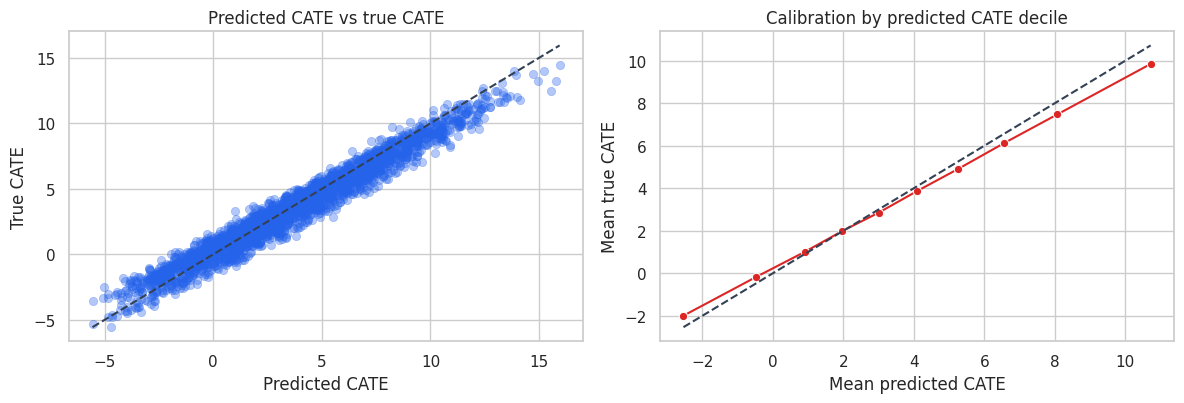

In [11]:
# Fit the models for this section and assemble the estimates used in the discussion.
test_df = test_df.copy()
test_df["cate_hat_interaction"] = predict_cate_from_interaction(
    interaction_model,
    test_df,
    feature_cols,
    feature_means,
    feature_stds,
)

cate_corr = np.corrcoef(test_df["cate_hat_interaction"], test_df["true_cate"])[0, 1]
cate_rmse = np.sqrt(mean_squared_error(test_df["true_cate"], test_df["cate_hat_interaction"]))

metrics = pd.DataFrame(
    {
        "metric": ["Correlation with true CATE", "CATE RMSE", "Mean predicted CATE", "Mean true CATE"],
        "value": [
            cate_corr,
            cate_rmse,
            test_df["cate_hat_interaction"].mean(),
            test_df["true_cate"].mean(),
        ],
    }
)
display(metrics.round(3))

calibration = test_df.copy()
calibration["predicted_cate_decile"] = pd.qcut(
    calibration["cate_hat_interaction"],
    10,
    labels=[f"D{i}" for i in range(1, 11)],
)
calibration_table = (
    calibration.groupby("predicted_cate_decile", observed=True)
    .agg(
        n=("account_id", "count"),
        mean_predicted_cate=("cate_hat_interaction", "mean"),
        mean_true_cate=("true_cate", "mean"),
    )
    .reset_index()
)
display(calibration_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_sample = test_df.sample(2500, random_state=19)
sns.scatterplot(
    data=plot_sample,
    x="cate_hat_interaction",
    y="true_cate",
    alpha=0.35,
    edgecolor=None,
    color="#2563eb",
    ax=axes[0],
)
line_min = min(plot_sample["cate_hat_interaction"].min(), plot_sample["true_cate"].min())
line_max = max(plot_sample["cate_hat_interaction"].max(), plot_sample["true_cate"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color="#334155", linestyle="--")
axes[0].set_title("Predicted CATE vs true CATE")
axes[0].set_xlabel("Predicted CATE")
axes[0].set_ylabel("True CATE")

sns.lineplot(
    data=calibration_table,
    x="mean_predicted_cate",
    y="mean_true_cate",
    marker="o",
    color="#dc2626",
    ax=axes[1],
)
cal_min = min(calibration_table["mean_predicted_cate"].min(), calibration_table["mean_true_cate"].min())
cal_max = max(calibration_table["mean_predicted_cate"].max(), calibration_table["mean_true_cate"].max())
axes[1].plot([cal_min, cal_max], [cal_min, cal_max], color="#334155", linestyle="--")
axes[1].set_title("Calibration by predicted CATE decile")
axes[1].set_xlabel("Mean predicted CATE")
axes[1].set_ylabel("Mean true CATE")

plt.tight_layout()
plt.show()

In this simulation, the interaction model recovers the broad CATE pattern well. That is not guaranteed in real data. It works here because the true effect is mostly a smooth function of a few measured covariates.

The calibration table is especially useful for industry work. We usually cannot verify individual treatment effects. We can still ask whether customers in higher predicted CATE buckets have higher experimental lift on average.

## 8. Honest Subgroup Discovery

A major risk in HTE analysis is searching for subgroups and estimating their effects on the same data. The more cuts we try, the more likely we are to find an impressive subgroup by chance.

Athey and Imbens (2016) emphasized honesty. Use one part of the data to discover the partition, and another part to estimate effects within the discovered leaves. This is an excellent workflow principle for valid HTE inference, even though other valid approaches exist.

For a randomized experiment with treatment probability $e=0.5$, one simple transformed outcome is:

$$
Y_i^* = Y_i \frac{W_i - e}{e(1-e)}
$$

Under random assignment, the conditional expectation of this transformed outcome is the CATE:

$$
E[Y_i^* \mid X_i=x] = \tau(x)
$$

We will fit a shallow tree to this transformed outcome on a discovery sample, then estimate treatment effects in the resulting leaves on a holdout sample.

|--- risk_score <= 0.14
|   |--- value: [-23.18]
|--- risk_score >  0.14
|   |--- risk_score <= 0.59
|   |   |--- risk_score <= 0.44
|   |   |   |--- value: [7.32]
|   |   |--- risk_score >  0.44
|   |   |   |--- value: [-4.13]
|   |--- risk_score >  0.59
|   |   |--- support_tickets <= 2.50
|   |   |   |--- value: [25.07]
|   |   |--- support_tickets >  2.50
|   |   |   |--- value: [7.04]



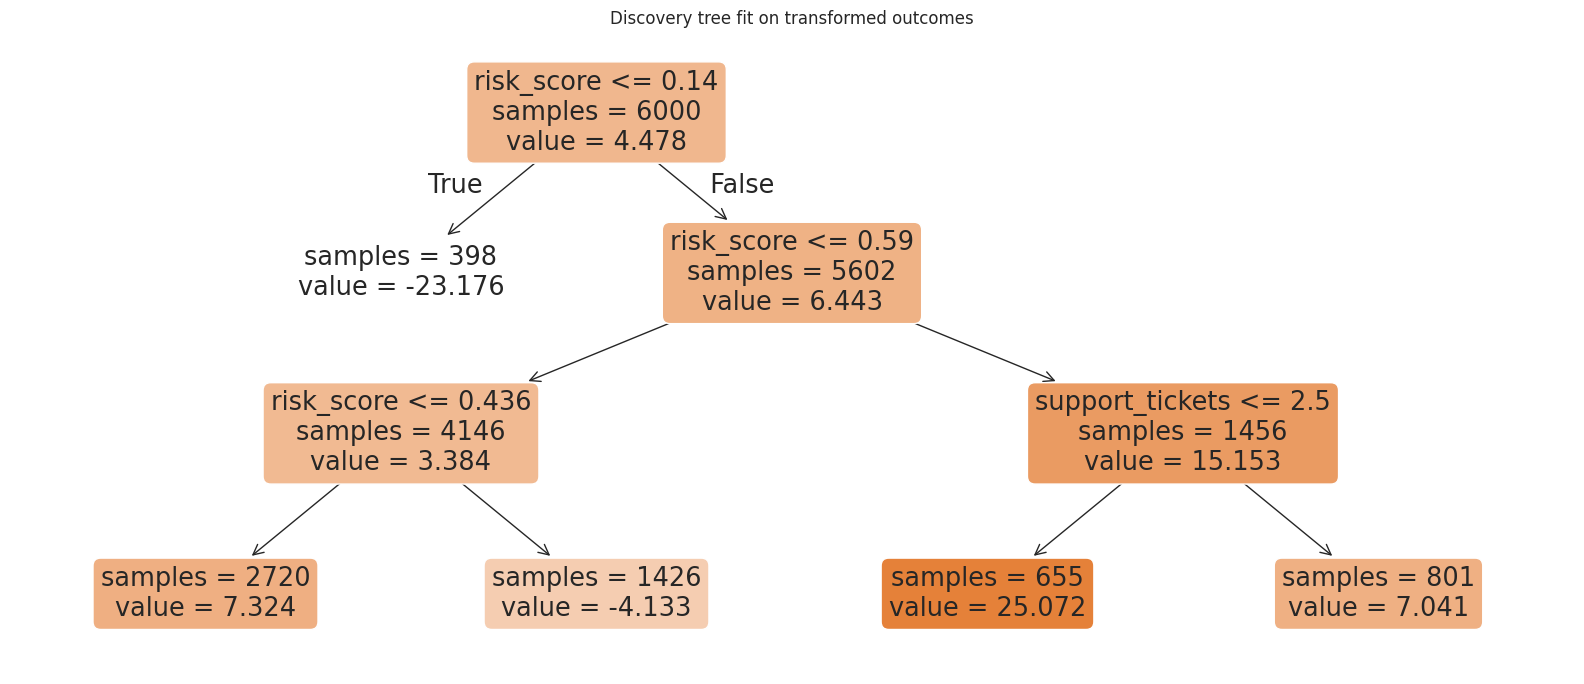

In [12]:
# Fit the models for this section and assemble the estimates used in the discussion.
tree_features = [
    "risk_score",
    "usage_z",
    "log_customer_value",
    "tenure_months",
    "enterprise_plan",
    "support_tickets",
]

experiment_discovery, experiment_holdout = train_test_split(
    df_model,
    test_size=0.50,
    random_state=99,
    stratify=df_model["treatment"],
)

propensity = 0.5
pseudo_outcome = experiment_discovery["outcome"] * (
    experiment_discovery["treatment"] - propensity
) / (propensity * (1 - propensity))

tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=350, random_state=11)
tree.fit(experiment_discovery[tree_features], pseudo_outcome)

print(export_text(tree, feature_names=tree_features, decimals=2))

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    tree,
    feature_names=tree_features,
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
)
ax.set_title("Discovery tree fit on transformed outcomes")
plt.tight_layout()
plt.show()

The tree is a discovery device. Its splits should be treated as hypotheses generated from data, not as final causal estimates. The next step estimates the treatment effect in each discovered leaf using data that the tree did not use for splitting.

,group,n,share_of_holdout,mean_risk_score,estimated_effect,std_error,ci_low,ci_high,true_cate_mean
0,Leaf 1,381,0.064,0.094,-1.388,1.275,-3.887,1.112,-1.757
1,Leaf 4,2752,0.459,0.300,1.282,0.483,0.336,2.228,1.423
2,Leaf 5,1440,0.240,0.510,4.845,0.709,3.455,6.235,4.686
3,Leaf 7,643,0.107,0.703,8.314,1.030,6.294,10.333,7.188
4,Leaf 8,784,0.131,0.723,9.266,0.942,7.420,11.111,8.360


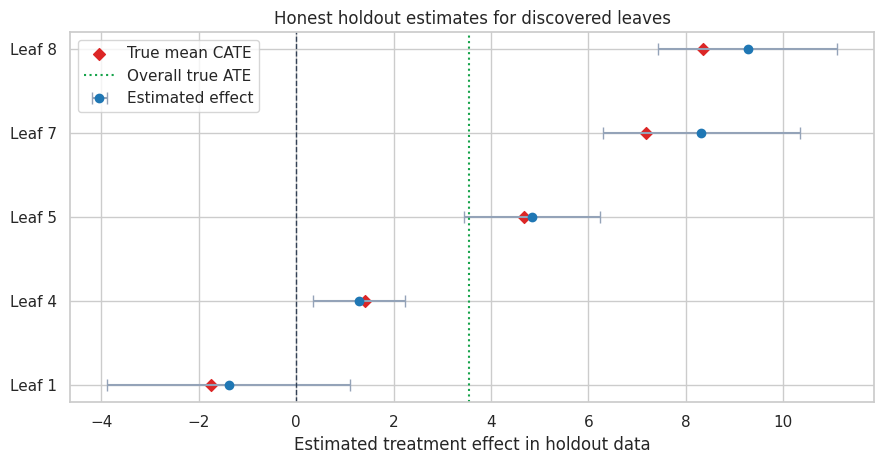

In [13]:
# Build the visualization for the estimates or diagnostics computed above.
holdout = experiment_holdout.copy()
holdout["leaf_id"] = tree.apply(holdout[tree_features])

leaf_table = subgroup_effect_table(holdout, "leaf_id")
leaf_table = leaf_table.sort_values("estimated_effect").reset_index(drop=True)
leaf_table["group"] = [f"Leaf {leaf}" for leaf in leaf_table["group"]]
leaf_table["share_of_holdout"] = leaf_table["n"] / len(holdout)

display(
    leaf_table[
        [
            "group",
            "n",
            "share_of_holdout",
            "mean_risk_score",
            "estimated_effect",
            "std_error",
            "ci_low",
            "ci_high",
            "true_cate_mean",
        ]
    ].round(3)
)

plot_effect_table(
    leaf_table,
    title="Honest holdout estimates for discovered leaves",
    xlabel="Estimated treatment effect in holdout data",
    reference=df["true_cate"].mean(),
    figsize=(9, 4.8),
)
plt.show()

The holdout estimates are noisier than the true leaf means, but they protect us from reporting purely in-sample discoveries as if they were confirmed effects. This matters in high-dimensional business datasets where hundreds of plausible segments can be searched.

A production-grade HTE workflow often repeats this logic with cross-fitting, causal forests, or doubly robust scores. Shin and Antonelli (2023) discuss doubly robust approaches for HTE inference, while Wager and Athey (2018) develop causal forests for nonparametric HTE estimation and inference.

## 9. From CATE to Targeting

CATE estimates become operationally useful when we convert them into a policy. Suppose the company can contact only 30% of eligible accounts. Which accounts should receive the retention offer?

We will compare several rules on the test sample:

- Treat everyone.
- Randomly contact 30%.
- Contact the highest-risk 30%.
- Contact the highest-value 30%.
- Contact the lowest predicted untreated-outcome 30%.
- Contact the highest predicted-CATE 30% using the interaction model.
- Oracle rule. Contact the highest true-CATE 30%. Real analysts cannot use this rule, so it serves as a benchmark only.

To include a practical constraint, assume the contact costs 2 revenue units per contacted account. A policy's net value per eligible account is:

$$
\text{Policy value} = P(\text{contact}) \times E[\tau(X) - c \mid \text{contact}]
$$

where $c$ is the contact cost.

In [14]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
control_train = train_df.loc[train_df["treatment"] == 0].copy()
rf_baseline = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=25,
    random_state=202,
    n_jobs=-1,
)
rf_baseline.fit(control_train[tree_features], control_train["outcome"])

test_policy = test_df.copy()
test_policy["predicted_y0"] = rf_baseline.predict(test_policy[tree_features])

contact_share = 0.30
contact_cost = 2.0
n_contact = int(np.floor(contact_share * len(test_policy)))

rng = np.random.default_rng(2026)
random_contact = pd.Series(False, index=test_policy.index)
random_contact.loc[rng.choice(test_policy.index.to_numpy(), size=n_contact, replace=False)] = True


def top_fraction_mask(series, fraction=0.30, largest=True):
    """Compute top fraction mask for the heterogeneous treatment effects example.
    
    Inputs:
    - `series`: series value used by `top_fraction_mask`.
    - `fraction`: fraction of units selected by a top-ranked targeting rule.
    - `largest`: whether larger scores should be treated as better when selecting top-ranked units.
    Returns: a Boolean mask or treatment rule selecting the highest-scoring share of units."""
    cutoff_n = int(np.floor(fraction * len(series)))
    selected_index = series.sort_values(ascending=not largest).head(cutoff_n).index
    mask = pd.Series(False, index=series.index)
    mask.loc[selected_index] = True
    return mask


policy_masks = {
    "Treat everyone": pd.Series(True, index=test_policy.index),
    "Random 30%": random_contact,
    "Highest risk 30%": top_fraction_mask(test_policy["risk_score"], contact_share, largest=True),
    "Highest value 30%": top_fraction_mask(test_policy["customer_value"], contact_share, largest=True),
    "Lowest predicted Y(0) 30%": top_fraction_mask(test_policy["predicted_y0"], contact_share, largest=False),
    "Highest predicted CATE 30%": top_fraction_mask(test_policy["cate_hat_interaction"], contact_share, largest=True),
    "Oracle highest true CATE 30%": top_fraction_mask(test_policy["true_cate"], contact_share, largest=True),
}

policy_rows = []
for policy_name, mask in policy_masks.items():
    targeted = test_policy.loc[mask]
    policy_rows.append(
        {
            "policy": policy_name,
            "target_share": mask.mean(),
            "mean_true_lift_if_targeted": targeted["true_cate"].mean(),
            "share_negative_lift_targeted": (targeted["true_cate"] < 0).mean(),
            "net_value_per_eligible_account": mask.mean() * (targeted["true_cate"].mean() - contact_cost),
        }
    )

policy_table = pd.DataFrame(policy_rows).sort_values("net_value_per_eligible_account", ascending=False)
display(policy_table.round(3))

,policy,target_share,mean_true_lift_if_targeted,share_negative_lift_targeted,net_value_per_eligible_account
6,Oracle highest true CATE 30%,0.300,7.878,0.000,1.763
5,Highest predicted CATE 30%,0.300,7.811,0.000,1.743
2,Highest risk 30%,0.300,7.487,0.000,1.646
0,Treat everyone,1.000,3.587,0.168,1.587
4,Lowest predicted Y(0) 30%,0.300,4.740,0.084,0.822
3,Highest value 30%,0.300,3.789,0.154,0.537
1,Random 30%,0.300,3.487,0.164,0.446


At this point, ask what the result lets us defend. The key is to separate the average effect from the customers where the action is worth taking.

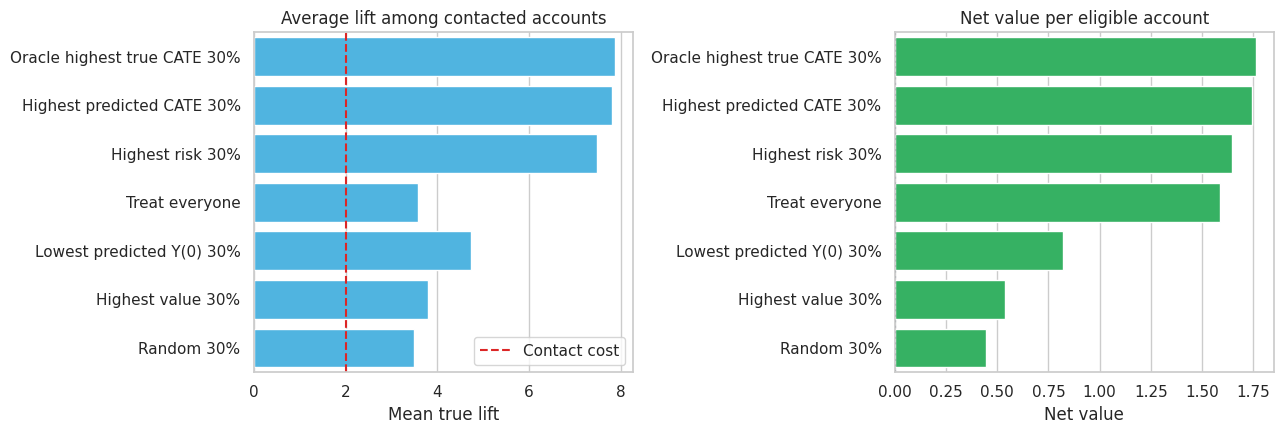

In [15]:
# Build the visualization for the estimates or diagnostics computed above.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(
    data=policy_table,
    y="policy",
    x="mean_true_lift_if_targeted",
    color="#38bdf8",
    ax=axes[0],
)
axes[0].axvline(contact_cost, color="#dc2626", linestyle="--", label="Contact cost")
axes[0].set_title("Average lift among contacted accounts")
axes[0].set_xlabel("Mean true lift")
axes[0].set_ylabel("")
axes[0].legend(loc="lower right")

sns.barplot(
    data=policy_table,
    y="policy",
    x="net_value_per_eligible_account",
    color="#22c55e",
    ax=axes[1],
)
axes[1].axvline(0, color="#334155", linestyle=":")
axes[1].set_title("Net value per eligible account")
axes[1].set_xlabel("Net value")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The CATE-based rule is close to the oracle benchmark and beats policies based only on high value or low predicted baseline outcome. This is the practical point of HTE modeling: ranking by expected outcome is not the same as ranking by expected incremental effect.

The treat-everyone policy can still have positive total value if the average effect is high enough. But when the budget is constrained or contact has customer-experience costs, the CATE-based rule can create more value per contacted account and avoid accounts with low or negative lift.

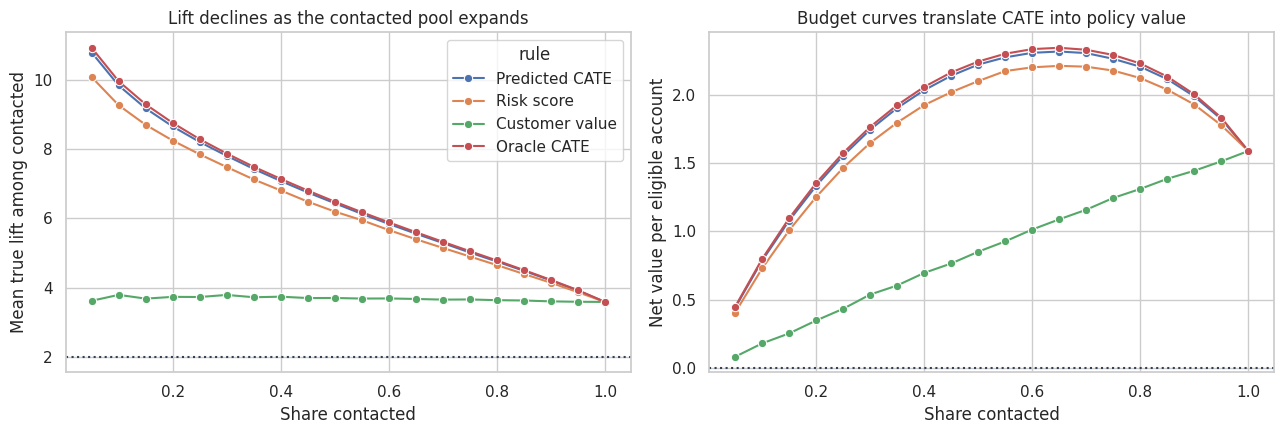

In [16]:
# Build the visualization for the estimates or diagnostics computed above.
fractions = np.linspace(0.05, 1.00, 20)
curve_rows = []

for fraction in fractions:
    for label, score, largest in [
        ("Predicted CATE", test_policy["cate_hat_interaction"], True),
        ("Risk score", test_policy["risk_score"], True),
        ("Customer value", test_policy["customer_value"], True),
        ("Oracle CATE", test_policy["true_cate"], True),
    ]:
        mask = top_fraction_mask(score, fraction, largest=largest)
        targeted = test_policy.loc[mask]
        curve_rows.append(
            {
                "contact_share": fraction,
                "rule": label,
                "mean_true_lift_targeted": targeted["true_cate"].mean(),
                "net_value_per_account": mask.mean() * (targeted["true_cate"].mean() - contact_cost),
            }
        )

curve_table = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(
    data=curve_table,
    x="contact_share",
    y="mean_true_lift_targeted",
    hue="rule",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(contact_cost, color="#334155", linestyle=":")
axes[0].set_title("Lift declines as the contacted pool expands")
axes[0].set_xlabel("Share contacted")
axes[0].set_ylabel("Mean true lift among contacted")

sns.lineplot(
    data=curve_table,
    x="contact_share",
    y="net_value_per_account",
    hue="rule",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0, color="#334155", linestyle=":")
axes[1].set_title("Budget curves translate CATE into policy value")
axes[1].set_xlabel("Share contacted")
axes[1].set_ylabel("Net value per eligible account")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

Budget curves are often more useful than a single top-30% policy. They show what happens as the available treatment capacity changes. A business team can use this view to choose a rollout threshold, estimate marginal returns, or negotiate campaign capacity.

## 10. How to Validate HTE Models in Practice

HTE validation is harder than outcome-prediction validation because individual treatment effects are unobserved. We cannot compute a row-level error metric like we can for prediction.

Useful validation strategies include:

- Holdout experimental lift by predicted-CATE bucket.
- Calibration curves comparing predicted CATE buckets with observed treatment-control differences.
- Policy value on a randomized holdout sample.
- Stability of discovered subgroups across time, geography, or cohorts.
- Sensitivity to feature sets, nuisance models, and targeting thresholds.
- Pre-registration of key subgroup hypotheses when the result will drive a major decision.
- Guardrails for harm, fairness, customer experience, and operational load.

Do not use post-treatment variables as effect modifiers. For example, if support tickets after outreach are included as features, the model may condition on a mediator or a downstream consequence of the treatment.

## 11. A Practical Readout Template

An HTE analysis should end with a decision-oriented summary, not only model diagnostics. A concise industry readout might look like this:

1. Overall effect: the retention offer increases next-quarter net revenue by the estimated ATE.
2. Main heterogeneity: effects rise sharply with pre-treatment risk score and are higher for enterprise accounts.
3. Low-lift segment: low-risk, high-usage accounts have little incremental benefit and may be excluded from outreach.
4. Proposed policy: contact the top 30% of accounts by predicted CATE.
5. Expected value: compare net value per eligible account against random targeting and current targeting.
6. Validation: monitor lift by predicted-CATE decile in the next randomized holdout.
7. Guardrails: track opt-outs, complaints, support load, and fairness across protected or policy-relevant groups.

The best HTE project is not the one with the most complex model. It is the one where the causal estimand, validation plan, and policy decision fit together.

In [17]:
readout = pd.DataFrame(
    {
        "question": [
            "Did the offer work on average?",
            "Where is lift highest?",
            "Which simple rule is a good baseline?",
            "Which model-based rule performs best?",
            "What should be validated next?",
        ],
        "answer_from_this_simulation": [
            f"Estimated ATE = {ate_stats['estimate']:.2f}; true ATE = {df['true_cate'].mean():.2f}.",
            "High-risk accounts and enterprise accounts show larger treatment effects.",
            "Highest-risk targeting is a strong transparent baseline.",
            "Highest predicted-CATE targeting is closest to the oracle benchmark.",
            "Run a holdout experiment and compare lift by predicted-CATE bucket.",
        ],
    }
)

display(readout)

,question,answer_from_this_simulation
0,Did the offer work on average?,Estimated ATE = 3.63; true ATE = 3.55.
1,Where is lift highest?,High-risk accounts and enterprise accounts sho...
2,Which simple rule is a good baseline?,Highest-risk targeting is a strong transparent...
3,Which model-based rule performs best?,Highest predicted-CATE targeting is closest to...
4,What should be validated next?,Run a holdout experiment and compare lift by p...


## 12. Common Failure Modes

HTE work can go wrong in predictable ways:

- Confusing high predicted outcome with high treatment responsiveness.
- Searching many subgroups and reporting only the most favorable one.
- Estimating subgroup effects on the same data used to discover the subgroup.
- Ignoring treatment cost, capacity, or customer-experience harm.
- Training on observational data without addressing confounding.
- Using features measured after treatment assignment.
- Reporting precise-looking individual effects when the reliable signal is only at the segment or bucket level.
- Deploying a targeting model without a randomized holdout to keep learning.

These failure modes explain why HTE is a causal workflow, not just a modeling task.

## Key Takeaways

- The CATE, $\tau(x)$, is the expected treatment effect for units with features $X=x$.
- A positive ATE can hide customers with low or negative treatment effects.
- Prognostic variables predict outcome levels; effect modifiers predict treatment responsiveness.
- Start HTE analysis with transparent subgroup estimates before moving to flexible models.
- Interaction models are useful baselines because they are interpretable and easy to validate by bucket.
- Honest sample splitting helps prevent overclaiming data-discovered subgroups.
- CATE models become valuable when translated into targeting policies and validated with holdout experimental lift.

## References

Athey, S., & Imbens, G. W. (2016). Recursive partitioning for heterogeneous causal effects. *Proceedings of the National Academy of Sciences, 113*(27), 7353-7360. https://doi.org/10.1073/pnas.1510489113

Hahn, P. R., Murray, J. S., & Carvalho, C. M. (2020). Bayesian regression tree models for causal inference: Regularization, confounding, and heterogeneous effects. *Bayesian Analysis, 15*(3), 965-1056. https://doi.org/10.1214/19-BA1195

Kunzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019). Metalearners for estimating heterogeneous treatment effects using machine learning. *Proceedings of the National Academy of Sciences, 116*(10), 4156-4165. https://doi.org/10.1073/pnas.1804597116

Park, C., & Kang, H. (2023). A groupwise approach for inferring heterogeneous treatment effects in causal inference. *Journal of the Royal Statistical Society Series A: Statistics in Society, 187*(2), 374-392. https://doi.org/10.1093/jrsssa/qnad125

Shin, H., & Antonelli, J. (2023). Improved inference for doubly robust estimators of heterogeneous treatment effects. *Biometrics, 79*(4), 3140-3152. https://doi.org/10.1111/biom.13837

Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random forests. *Journal of the American Statistical Association, 113*(523), 1228-1242. https://doi.org/10.1080/01621459.2017.1319839